## Data Analysis and Preprocessing

1. Import necessary libraries and telecom table

In [ ]:
import pandas as pd

df = pd.read_csv("churn-bigml-20.csv")

display(df.head())
display(df.columns)

shape = df.shape

display(shape)
print(f"{shape[0]} customers in total")

,State,Account length,Area code,International plan,Voice mail plan,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls,Churn
0,LA,117,408,No,No,0,184.5,97,31.37,351.6,80,29.89,215.8,90,9.71,8.7,4,2.35,1,False
1,IN,65,415,No,No,0,129.1,137,21.95,228.5,83,19.42,208.8,111,9.40,12.7,6,3.43,4,True
2,NY,161,415,No,No,0,332.9,67,56.59,317.8,97,27.01,160.6,128,7.23,5.4,9,1.46,4,True
3,SC,111,415,No,No,0,110.4,103,18.77,137.3,102,11.67,189.6,105,8.53,7.7,6,2.08,2,False
4,HI,49,510,No,No,0,119.3,117,20.28,215.1,109,18.28,178.7,90,8.04,11.1,1,3.00,1,False


Index(['State', 'Account length', 'Area code', 'International plan',
       'Voice mail plan', 'Number vmail messages', 'Total day minutes',
       'Total day calls', 'Total day charge', 'Total eve minutes',
       'Total eve calls', 'Total eve charge', 'Total night minutes',
       'Total night calls', 'Total night charge', 'Total intl minutes',
       'Total intl calls', 'Total intl charge', 'Customer service calls',
       'Churn'],
      dtype='object')

(667, 20)

667 customers in total


2. Find how many customers left the telecom

In [3]:
churn = df["Churn"]

churn.value_counts()

Churn
False    572
True      95
Name: count, dtype: int64

3. Switch to SQL for Data Analysis

### International Plan vs Churn Rate

**Hypothesis:** Customers on an international plan are more likely to churn 
due to potentially higher costs or dissatisfaction with international call quality.

In [4]:
import sqlite3

conn = sqlite3.connect("telecom.db")
df.to_sql('customers', conn, if_exists = 'replace', index = False)

display(df.head())

#1. Check the churn rate for international plan customers
international_churn = pd.read_sql_query('''SELECT "International plan", COUNT(*), SUM(Churn), ROUND(SUM(Churn) * 100.0 / COUNT(*), 1) as Churn_rate
                  FROM customers
                  GROUP BY "International plan"''', conn)
display(international_churn)


,State,Account length,Area code,International plan,Voice mail plan,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls,Churn
0,LA,117,408,No,No,0,184.5,97,31.37,351.6,80,29.89,215.8,90,9.71,8.7,4,2.35,1,False
1,IN,65,415,No,No,0,129.1,137,21.95,228.5,83,19.42,208.8,111,9.40,12.7,6,3.43,4,True
2,NY,161,415,No,No,0,332.9,67,56.59,317.8,97,27.01,160.6,128,7.23,5.4,9,1.46,4,True
3,SC,111,415,No,No,0,110.4,103,18.77,137.3,102,11.67,189.6,105,8.53,7.7,6,2.08,2,False
4,HI,49,510,No,No,0,119.3,117,20.28,215.1,109,18.28,178.7,90,8.04,11.1,1,3.00,1,False


,International plan,COUNT(*),SUM(Churn),Churn_rate
0,No,614,76,12.4
1,Yes,53,19,35.8


### International Plan Customers vs Churn Rate

**Conclusion**: Customers who are on international plan left 3 times more than the customers on the domestic plan.

**Business Recommendation**: Telecompany should consider detecting the issues with and improving the international plan. Customer satisfaction surveys can be done to identify the issues with international plan.

### Customer Service Calls vs Churn Rate
**Hypothesis**: Customers who call the customer service more are more likely to churn

In [5]:
#2. Check the churn rate for by the number of customer service calls
service_churn = pd.read_sql_query('''SELECT "Customer service calls", COUNT(*), SUM(Churn), ROUND(SUM(Churn) * 100.0 / COUNT(*), 1) as Churn_rate
                          FROM customers
                          GROUP BY "Customer service calls"''', conn)
display(service_churn)

,Customer service calls,COUNT(*),SUM(Churn),Churn_rate
0,0,142,13,9.2
1,1,236,23,9.7
2,2,151,25,16.6
3,3,81,7,8.6
4,4,33,12,36.4
5,5,17,11,64.7
6,6,5,4,80.0
7,7,1,0,0.0
8,8,1,0,0.0


**Conclusion**: churn rate jumps from ~10% to 80% as calls increase from 0 to 6.

**Business recommendation**: flag customers with 4+ service calls for proactive retention.

### Voice Mail Plan vs Churn Rate

**Hypothesis**: Customers on Voice Mail Plan churn less because they are more engaged/satisfied with an operator 

In [6]:
voice_mail_churn = pd.read_sql_query('''SELECT "Voice mail plan", COUNT(*), SUM(Churn), ROUND((SUM(Churn) * 100 / COUNT(*)), 1) as Churn_rate
                  FROM customers
                  GROUP BY "Voice mail plan"''', conn)
display(voice_mail_churn)

,Voice mail plan,COUNT(*),SUM(Churn),Churn_rate
0,No,478,80,16.0
1,Yes,189,15,7.0


**Conlusion**: Our Hypothesis confirmed. Customers who are on voice mail plan churn 2x less than customers without a voice on mail plan

**Business Recommendation**: This shows that customers who use more services are less likely to churn, and so company should consider selling products in bundle and making a full ecosystem for customer retention.

### Heavy Users Churn Rate

**Hypothesis**: Customers who talk more tend to churn less because they pay higher amount to the telecom operator and hence more satisfied with the services.

In [7]:
df['Total minutes'] = df['Total day minutes'] + df['Total eve minutes'] + df['Total night minutes'] + df['Total intl minutes']
df['Total charge'] = df['Total day charge'] + df['Total eve charge'] + df['Total night charge'] + df['Total intl charge']

print("Data stats description for the Total day minutes column:")
display(df['Total day minutes'].describe())

print("\nData stats description for the Total night minutes column:")
display(df['Total night minutes'].describe())

print("\nData stats description for the Total eve minutes column:")
display(df['Total eve minutes'].describe())

#The most important: Description of the Total minutes column
print("\nData stats description for the Total minutes column:")
display(df['Total minutes'].describe())

#Description of the Total charge column
display(df['Total charge'].describe())

Data stats description for the Total day minutes column:


count    667.000000
mean     180.948126
std       55.508628
min       25.900000
25%      146.250000
50%      178.300000
75%      220.700000
max      334.300000
Name: Total day minutes, dtype: float64


Data stats description for the Total night minutes column:


count    667.000000
mean     199.685307
std       49.759931
min       23.200000
25%      167.950000
50%      201.600000
75%      231.500000
max      367.700000
Name: Total night minutes, dtype: float64


Data stats description for the Total eve minutes column:


count    667.000000
mean     203.355322
std       49.719268
min       48.100000
25%      171.050000
50%      203.700000
75%      236.450000
max      361.800000
Name: Total eve minutes, dtype: float64


Data stats description for the Total minutes column:


count    667.000000
mean     594.227136
std       88.893973
min      301.500000
25%      534.250000
50%      592.100000
75%      650.400000
max      882.200000
Name: Total minutes, dtype: float64

count    667.000000
mean      59.797886
std       10.584342
min       27.080000
25%       52.795000
50%       59.880000
75%       66.000000
max       92.290000
Name: Total charge, dtype: float64

In [8]:
#Low: < 146 minutes (bottom 25%) | Medium: 146-220 minutes (middle 50%) | High: > 220 minutes (top 25%)

#Update SQL since we added a new column to our data frame
df.to_sql('customers', conn, if_exists='replace', index=False)

heavy_users_churn = pd.read_sql_query('''SELECT 
                        CASE 
                            WHEN "Total minutes" < 534 THEN 'Low_usage'
                            WHEN "Total minutes" BETWEEN 534 and 650 THEN 'Medium_usage'
                            ELSE 'High_usage'
                        END AS usage_category,
                        COUNT(*) as total_customers,
                        SUM(Churn) as churned,
                        ROUND(SUM(Churn) * 100.0 / COUNT(*), 1) as Churn_rate
                    FROM customers
                    GROUP BY usage_category
                    ORDER BY CASE usage_category 
                                WHEN 'Low_usage' THEN 1 
                                WHEN 'Medium_usage' THEN 2 
                                ELSE 3 
                            END''', conn)

display(heavy_users_churn)

display(pd.read_sql_query('''SELECT
                        CASE 
                            WHEN "Total charge" < 52.8 THEN "Low_paying"
                            WHEN "Total charge" BETWEEN 52.8 and 66 THEN "Medium_paying"
                            ELSE "High_paying"
                        END AS payment_category,
                        COUNT(*) as total_customers,
                        SUM(Churn) as churned,
                        ROUND(SUM(Churn) * 100.0 / COUNT(*), 1) as Churn_rate
                    FROM customers
                    GROUP BY payment_category
                    ORDER BY Churn_rate DESC''', conn))

,usage_category,total_customers,churned,Churn_rate
0,Low_usage,166,20,12.0
1,Medium_usage,333,19,5.7
2,High_usage,168,56,33.3


,payment_category,total_customers,churned,Churn_rate
0,High_paying,167,56,33.5
1,Low_paying,167,21,12.6
2,Medium_paying,333,18,5.4


**Conclusion**: My hypothesis was wrong. Heavy customers are ~3x more likely to churn than low usage customers and ~6x more likely to leave than medium usage customers. 
- Probably because, contrary to the common assumption of higher paying customer = more loyal customer, the reality is that higher paying customer cares more about the quality of the telecom service and more likely to afford better deals in other telecom services. 
- We see that usage and payments are essentially the same signal - high usage customers pay more, so both tables confirm the same finding. Medium usage customers are the most loyal (5.7% churn) — they use the service enough to value it but not so much that they're price-sensitive

**Business Recommendation**: Since higher using and paying customers tend to leave more, identify the problem why they can be unhappy with the service. 
- Adding premium perks or special discounts can be a good idea. 
- There is a possiblity that it is essential for heavy users to call more (so they are doing it not because they are rich, but because they need to) and so they are unhappy with the high bills they end up paying. Maybe in other telecom company, there is a better deal for heavy users calling a lot. 
- Don't over-invest in acquiring heavy users — if they churn 3x more, the customer lifetime value might be lower than expected despite high monthly bills.
- Medium users are the sweet spot — most loyal segment, telecompany should identify what makes them stay and replicate that for other segments

## Data visualizations using matplotlib

1. International Plan vs Churn Rate 

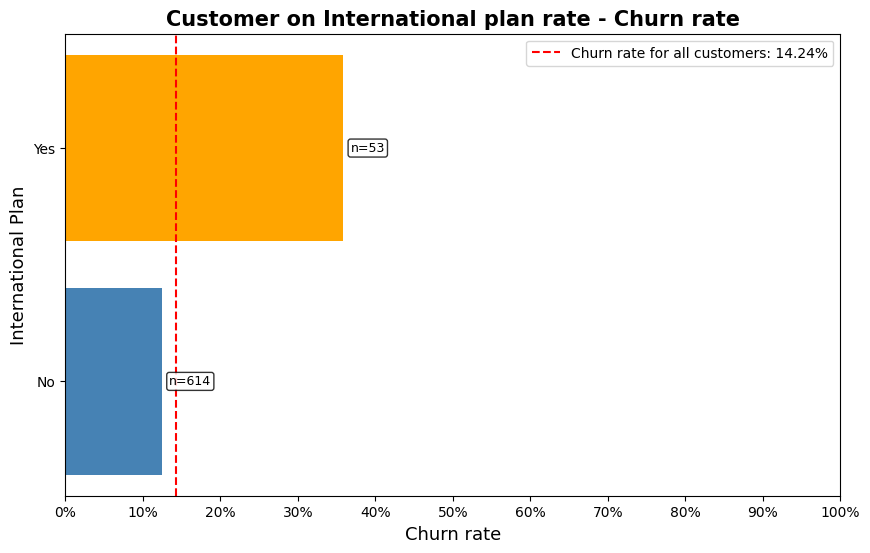

In [13]:
import matplotlib.pyplot as plt

all_churn_rate = df["Churn"].sum() * 100 / 667

x_values = international_churn['International plan']
y_values = international_churn['Churn_rate']

colors = ["orange" if rate >= all_churn_rate else "steelblue" for rate in y_values]

plt.figure(figsize=(10, 6))
plt.barh(x_values, y_values, color=colors)

plt.axvline(all_churn_rate, color = 'r', linestyle = '--', label = f"Churn rate for all customers: {all_churn_rate:.2f}%")

plt.title("Customer on International plan rate - Churn rate", fontsize = 15, fontweight = "bold")
plt.xlabel("Churn rate", fontsize = 13)
plt.ylabel("International Plan", fontsize = 13)

plt.xticks([0, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100], 
           ['0%', '10%', '20%', '30%', '40%', '50%', '60%', '70%', '80%', '90%', '100%'])

for i, (count, rate) in enumerate(zip(international_churn["COUNT(*)"], y_values)):
    plt.text(rate + 1, i, f"n={count}", va='center', fontsize=9,
         bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.8))

plt.legend()

plt.show()

2. Customer Service vs Churn Rate (Bar Chart)

,Customer service calls,COUNT(*),SUM(Churn),Churn_rate
0,0,142,13,9.2
1,1,236,23,9.7
2,2,151,25,16.6
3,3,81,7,8.6
4,4,33,12,36.4
5,5,17,11,64.7
6,6,5,4,80.0
7,7,1,0,0.0
8,8,1,0,0.0


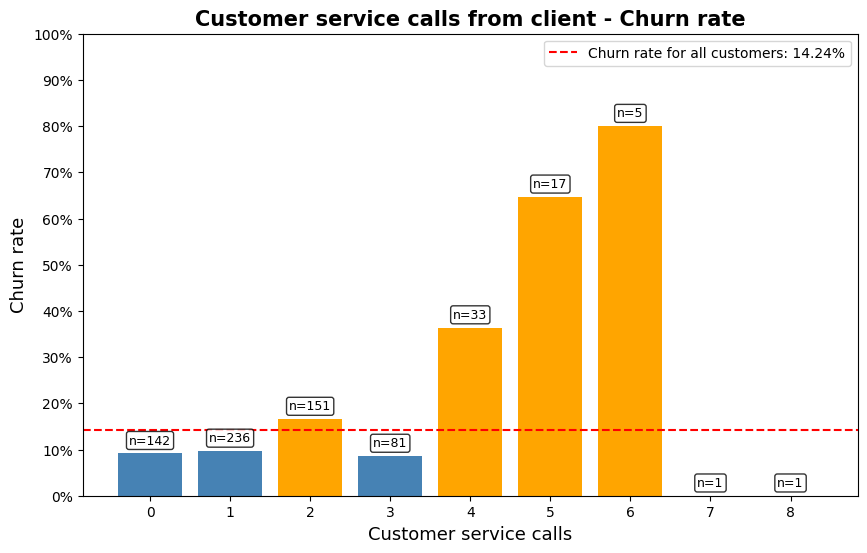

In [10]:
display(service_churn)

x_values = service_churn["Customer service calls"]
y_values = service_churn["Churn_rate"]

colors = ["orange" if rate >= all_churn_rate else "steelblue" for rate in y_values]

plt.figure(figsize = (10, 6))
plt.bar(x_values, y_values, color=colors)
plt.axhline(all_churn_rate, color = 'r', linestyle = '--', label = f"Churn rate for all customers: {all_churn_rate:.2f}%")
plt.title("Customer service calls from client - Churn rate", fontsize = 15, fontweight = "bold")
plt.xlabel("Customer service calls", fontsize = 13)
plt.ylabel("Churn rate", fontsize = 13)
plt.xticks(x_values)
plt.yticks([0, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100], 
           ['0%', '10%', '20%', '30%', '40%', '50%', '60%', '70%', '80%', '90%', '100%'])

for i, (count, rate) in enumerate(zip(service_churn["COUNT(*)"], y_values)):
    plt.text(x_values.iloc[i], rate + 2, f"n={count}", ha = 'center', fontsize = 9,
              bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.8))

plt.legend()

plt.show()

3. Voice Mail vs Churn Rate

,Voice mail plan,COUNT(*),SUM(Churn),Churn_rate
0,No,478,80,16.0
1,Yes,189,15,7.0


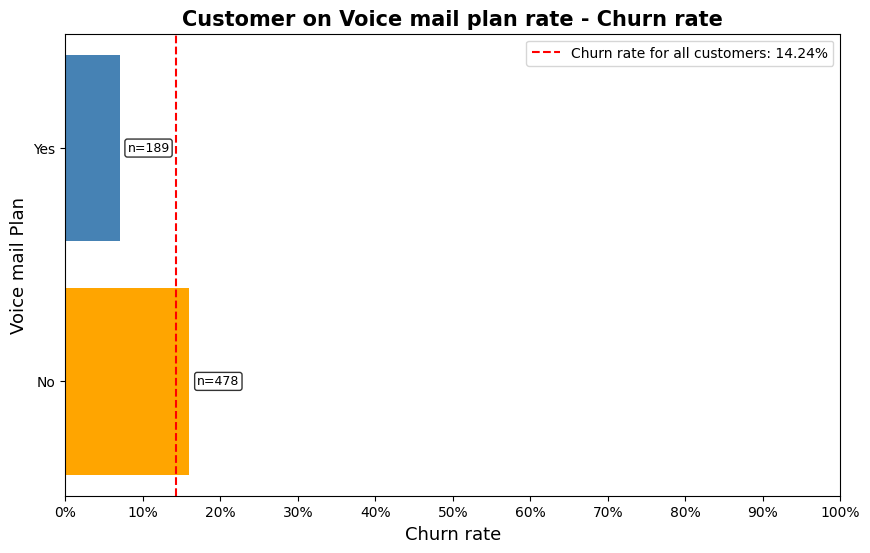

In [11]:
x_values = voice_mail_churn['Voice mail plan']
y_values = voice_mail_churn['Churn_rate']

display(voice_mail_churn)

colors = ["orange" if rate >= all_churn_rate else "steelblue" for rate in y_values]

plt.figure(figsize=(10, 6))
plt.barh(x_values, y_values, color=colors)

plt.axvline(all_churn_rate, color = 'r', linestyle = '--', label = f"Churn rate for all customers: {all_churn_rate:.2f}%")

plt.title("Customer on Voice mail plan rate - Churn rate", fontsize = 15, fontweight = "bold")
plt.xlabel("Churn rate", fontsize = 13)
plt.ylabel("Voice mail Plan", fontsize = 13)

plt.xticks([0, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100], 
           ['0%', '10%', '20%', '30%', '40%', '50%', '60%', '70%', '80%', '90%', '100%'])

for i, (count, rate) in enumerate(zip(voice_mail_churn["COUNT(*)"], y_values)):
    plt.text(rate + 1, i, f"n={count}", va='center', fontsize=9,
         bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.8))

plt.legend()

plt.show()

4. Usage Category vs Churn Rate

,usage_category,total_customers,churned,Churn_rate
0,Low_usage,166,20,12.0
1,Medium_usage,333,19,5.7
2,High_usage,168,56,33.3


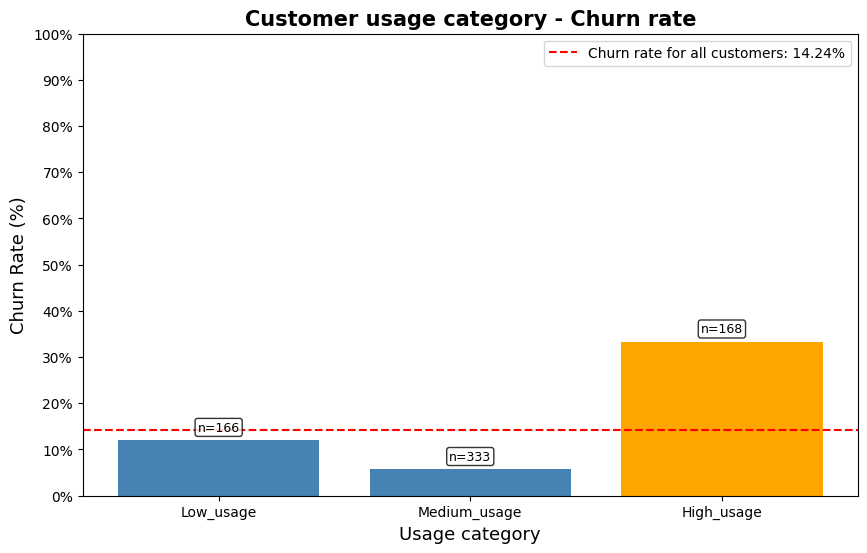

In [14]:
display(heavy_users_churn)

x_values = heavy_users_churn["usage_category"]
y_values = heavy_users_churn["Churn_rate"]

colors = ["orange" if rate >= all_churn_rate else "steelblue" for rate in y_values]

plt.figure(figsize=(10, 6))
plt.bar(x_values, y_values, color=colors)
plt.axhline(all_churn_rate, color = 'r', linestyle = '--', label = f"Churn rate for all customers: {all_churn_rate:.2f}%")
plt.yticks([0, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100], 
           ['0%', '10%', '20%', '30%', '40%', '50%', '60%', '70%', '80%', '90%', '100%'])

plt.title("Customer usage category - Churn rate", fontsize = 15, fontweight = "bold")
plt.xlabel("Usage category", fontsize = 13)
plt.ylabel("Churn Rate (%)", fontsize = 13)

for i, (count, rate) in enumerate(zip(heavy_users_churn["total_customers"], y_values)):
    plt.text(x_values.iloc[i], rate + 2, f"n={count}", ha = 'center', fontsize = 9, 
             bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.8))

plt.legend()

plt.show()

conn.close()

## Key Findings Summary

| Finding | Churn Rate | vs Average (14.24%) |
|---------|-----------|---------------------|
| International plan: Yes | 35.8% | 2.5x higher |
| Customer service calls 6+ | 80% | 5.6x higher |
| Voice mail plan: No | 16% | Higher |
| High usage customers | 33.3% | 2.3x higher |

**Main recommendation:** Focus retention efforts on customers with 
international plan and customers with high (4+) customer service calls — they are at 
highest churn risk.